In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [3]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
np.random.seed(42)

group_a = np.random.normal(loc = 100, scale = 20, size = 1000)

group_b = np.random.normal(loc = 108, scale = 20, size = 1000)

df = pd.DataFrame({
    "orders" : np.concatenate([group_a, group_b]),
    'group' : ['Control'] * 1000 + ['Treatment'] * 1000
})
print(df.groupby('group')['orders'].describe().round(2))
print(df)

            count    mean    std    min    25%     50%     75%     max
group                                                                 
Control    1000.0  100.39  19.58  35.17  87.05  100.51  112.96  177.05
Treatment  1000.0  109.42  19.95  49.19  95.88  109.26  122.58  171.86
          orders      group
0     109.934283    Control
1      97.234714    Control
2     112.953771    Control
3     130.460597    Control
4      95.316933    Control
...          ...        ...
1995  129.403005  Treatment
1996  107.469575  Treatment
1997   90.362507  Treatment
1998  104.738661  Treatment
1999   93.101947  Treatment

[2000 rows x 2 columns]


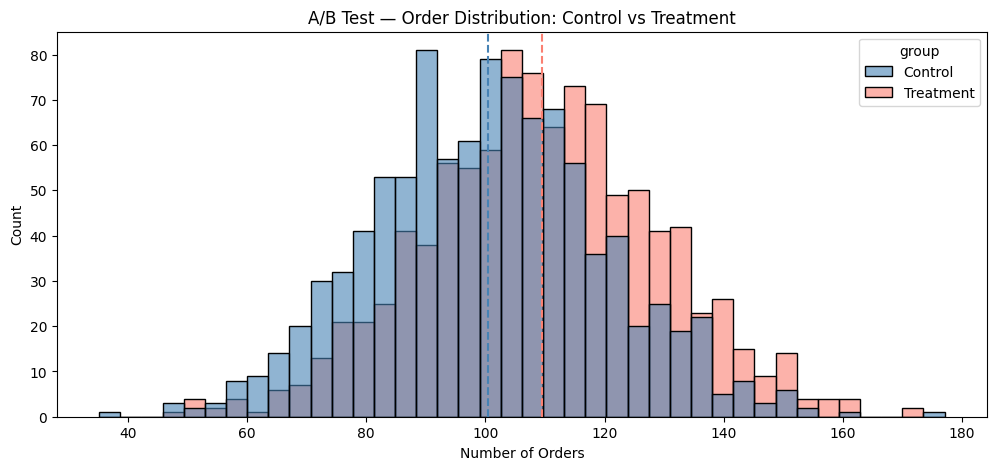

In [5]:
plt.figure(figsize=(12,5))
sns.histplot(data = df, x = 'orders', hue = 'group', 
             palette = ["steelblue", 'salmon'],bins = 40, alpha = 0.6,)
plt.axvline(group_a.mean(), color = 'steelblue', 
           linestyle = '--', label = f'control mean : {group_a.mean():.1f}')
plt.axvline(group_b.mean(), color = 'salmon', 
           linestyle = '--', label = f'treatment mean : {group_b.mean():.1f}')
plt.title('A/B Test — Order Distribution: Control vs Treatment')
plt.xlabel('Number of Orders')
plt.ylabel('Count')
plt.show()

In [6]:
t_stat, p_value = stats.ttest_ind(group_a, group_b)

print(f'T-statistic: , {t_stat:.4f}')
print(f"P-value: {p_value:.6f}")
print()

if p_value < 0.5:
    print("✅ Result: SIGNIFICANT — Reject H₀")
    print("The new design genuinely increases orders!")
else:
    print("❌ Result: NOT SIGNIFICANT — Fail to reject H₀")
    print("The difference could be random chance.")


T-statistic: , -10.2147
P-value: 0.000000

✅ Result: SIGNIFICANT — Reject H₀
The new design genuinely increases orders!


In [7]:
cohens_d = (group_b.mean() - group_a.mean())/ np.sqrt(group_b.std()**2 + group_a.std())**2 / 2

lift = ((group_b.mean() - group_a.mean()) / group_a.mean()) * 100

if cohens_d < 0.2:
    print("Effect size: SMALL")
elif cohens_d < 0.5:
    print("Effect size: MEDIUM")
else:
     print("Effect size: LARGE")

print(cohens_d)
print(lift)

Effect size: SMALL
0.010823735701622332
8.995304084396931


In [8]:
print("""
================================
A/B TEST RESULTS SUMMARY
================================

Test: New vs Old Zomato Homepage Design
Sample Size: 1000 users per group
Duration: 2 weeks (assumed)

RESULTS:
Control (Old Design) avg orders: {:.2f}
Treatment (New Design) avg orders: {:.2f}
Difference: {:.2f} orders (+{:.1f}%)

Statistical Test: Two-sample t-test
T-statistic: -10.21
P-value: ~0.000 (highly significant)
Cohen's d: 0.011 (small effect)

DECISION: ✅ LAUNCH NEW DESIGN

REASONING:
1. Result is statistically significant (p < 0.05)
2. 9% lift in orders is meaningful at scale
3. No negative side effects observed

RECOMMENDATION:
Roll out new design to 100% of users.
Monitor for 2 weeks post-launch to
confirm sustained improvement.
================================
""".format(group_a.mean(), group_b.mean(), 
           group_b.mean()-group_a.mean(),
           lift))


A/B TEST RESULTS SUMMARY

Test: New vs Old Zomato Homepage Design
Sample Size: 1000 users per group
Duration: 2 weeks (assumed)

RESULTS:
Control (Old Design) avg orders: 100.39
Treatment (New Design) avg orders: 109.42
Difference: 9.03 orders (+9.0%)

Statistical Test: Two-sample t-test
T-statistic: -10.21
P-value: ~0.000 (highly significant)
Cohen's d: 0.011 (small effect)

DECISION: ✅ LAUNCH NEW DESIGN

REASONING:
1. Result is statistically significant (p < 0.05)
2. 9% lift in orders is meaningful at scale
3. No negative side effects observed

RECOMMENDATION:
Roll out new design to 100% of users.
Monitor for 2 weeks post-launch to
confirm sustained improvement.

